Assignment no 5.Server-Side Model Aggregation Using Weighted Federated Averaging and Global Model
Distribution in Federated Learning

**Install & Imports**

In [1]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset


**Define Global Model**

In [2]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


**Load MNIST Dataset**

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.91MB/s]


**Create Federated Clients**

In [4]:
num_clients = 3

data_per_client = len(train_dataset) // num_clients
client_indices = [list(range(i * data_per_client, (i+1) * data_per_client)) for i in range(num_clients)]

clients = []
for indices in client_indices:
    subset = Subset(train_dataset, indices)
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    clients.append(loader)

print("Clients created successfully.")


Clients created successfully.


**Client Local Training Function**

In [5]:
def train_client(model, loader, epochs=1):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for data, target in loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    return model.state_dict(), len(loader.dataset)


**Weighted Federated Averaging (SERVER SIDE)**

In [6]:
def weighted_fedavg(client_weights, client_sizes):
    global_weights = copy.deepcopy(client_weights[0])
    total_samples = sum(client_sizes)

    for key in global_weights.keys():
        global_weights[key] = sum(
            client_weights[i][key] * (client_sizes[i] / total_samples)
            for i in range(len(client_weights))
        )

    return global_weights


**Evaluation Function**

In [7]:
def evaluate(model, test_dataset):
    model.eval()
    loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return 100 * correct / total


**Federated Training Process**

In [8]:
global_model = SimpleNN()
rounds = 5
accuracy_list = []

for r in range(rounds):
    print(f"\n--- Communication Round {r+1} ---")

    client_weights = []
    client_sizes = []

    # Send global model to clients
    for client_loader in clients:
        local_model = copy.deepcopy(global_model)
        weights, size = train_client(local_model, client_loader, epochs=1)
        client_weights.append(weights)
        client_sizes.append(size)

    # Server aggregation
    global_weights = weighted_fedavg(client_weights, client_sizes)
    global_model.load_state_dict(global_weights)

    # Evaluate global model
    acc = evaluate(global_model, test_dataset)
    accuracy_list.append(acc)

    print(f"Global Model Accuracy: {acc:.2f}%")



--- Communication Round 1 ---
Global Model Accuracy: 82.32%

--- Communication Round 2 ---
Global Model Accuracy: 87.68%

--- Communication Round 3 ---
Global Model Accuracy: 89.28%

--- Communication Round 4 ---
Global Model Accuracy: 89.93%

--- Communication Round 5 ---
Global Model Accuracy: 90.61%


**Plot Accuracy Per Round**

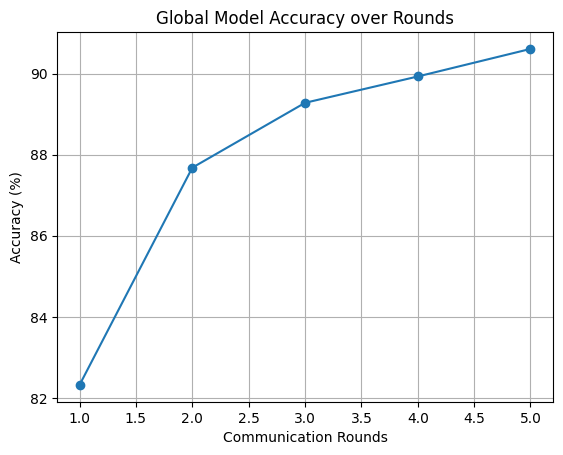

In [9]:
plt.plot(range(1, rounds+1), accuracy_list, marker='o')
plt.title("Global Model Accuracy over Rounds")
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()
